In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import pandas as pd

df = pd.read_csv("tips_200.csv")

In [7]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,25.60,6.78,Male,No,Sat,Dinner,4
1,57.29,1.76,Female,No,Sat,Lunch,6
2,45.26,2.45,Male,No,Thur,Dinner,3
3,37.93,9.09,Male,No,Fri,Dinner,5
4,13.58,6.46,Female,No,Fri,Dinner,1


Correlation with Heatmap

In [9]:
df.dtypes

total_bill    float64
tip           float64
sex               str
smoker            str
day               str
time              str
size            int64
dtype: object

In [13]:
numeric_df = df[["total_bill", "tip", "size"]]

In [14]:
corr_matrix = numeric_df.corr()

print(corr_matrix)

            total_bill       tip      size
total_bill    1.000000 -0.026921  0.079000
tip          -0.026921  1.000000 -0.065791
size          0.079000 -0.065791  1.000000


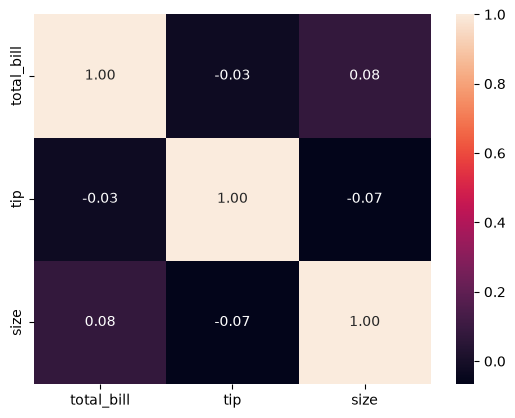

In [24]:
sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="rocket",
            fmt=".2f")

plt.show()

Join plot

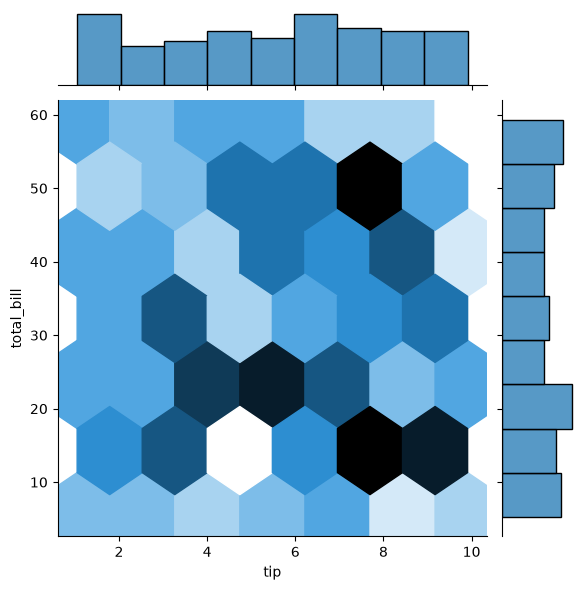

In [25]:
sns.jointplot(x='tip',y='total_bill',data=df,kind='hex')

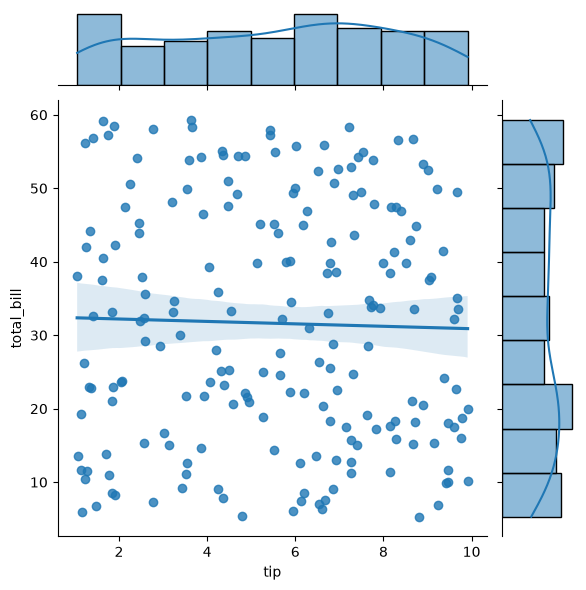

In [26]:
sns.jointplot(x='tip',y='total_bill',data=df,kind='reg')

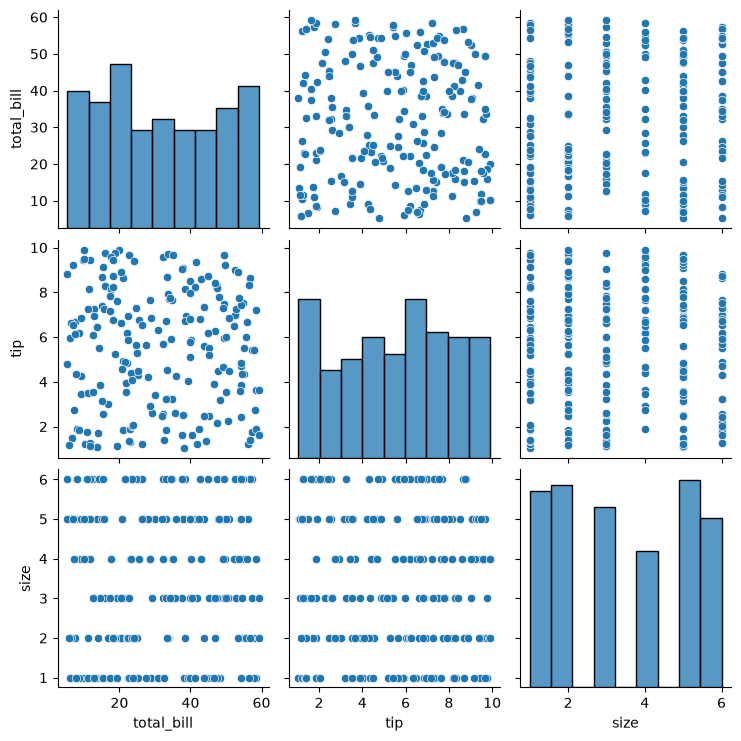

In [27]:
sns.pairplot(df)

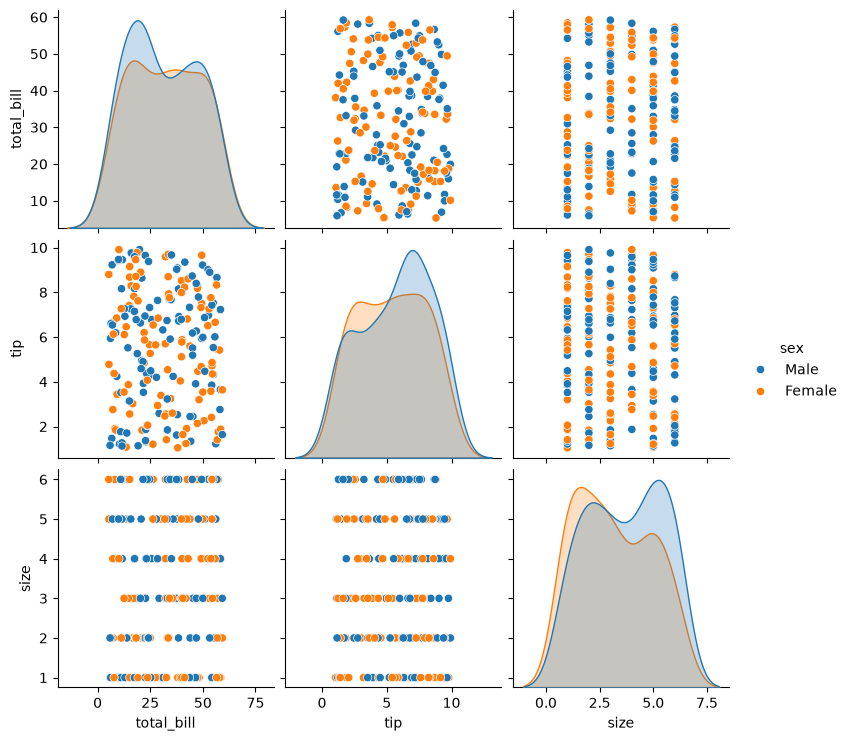

In [28]:
sns.pairplot(df,hue='sex')

Annoted chart

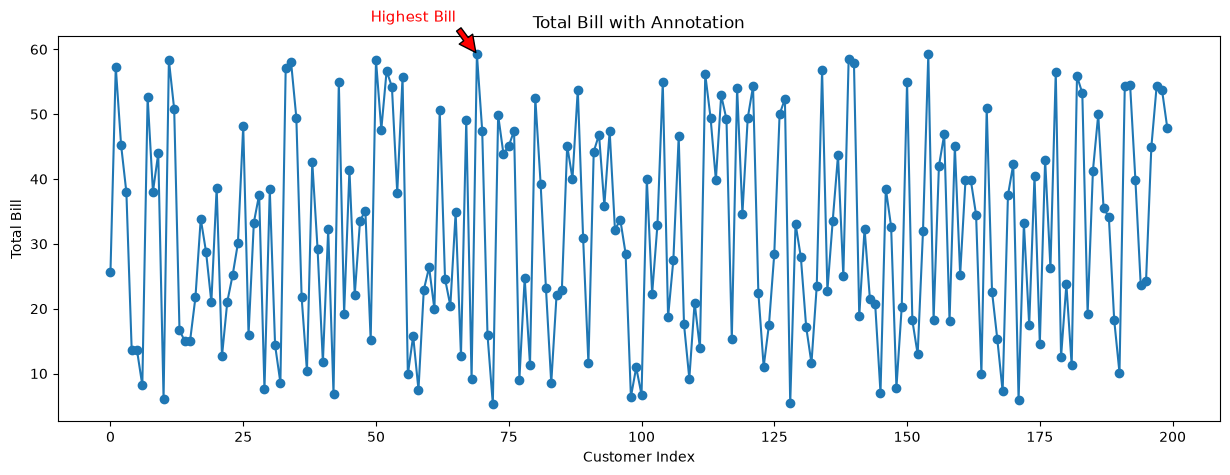

In [32]:
import matplotlib.pyplot as plt

# Find the row with the maximum total_bill
max_bill = df["total_bill"].max()
max_index = df["total_bill"].idxmax()

plt.figure(figsize=(15,5))

plt.plot(df.index, df["total_bill"], marker='o')

plt.annotate(
    "Highest Bill",
    xy=(max_index, max_bill),
    xytext=(max_index-20, max_bill+5),
    arrowprops=dict(facecolor='red', shrink=0.05),
    fontsize=11,
    color='red'
)

plt.title("Total Bill with Annotation")
plt.xlabel("Customer Index")
plt.ylabel("Total Bill")

plt.show()

misleading 

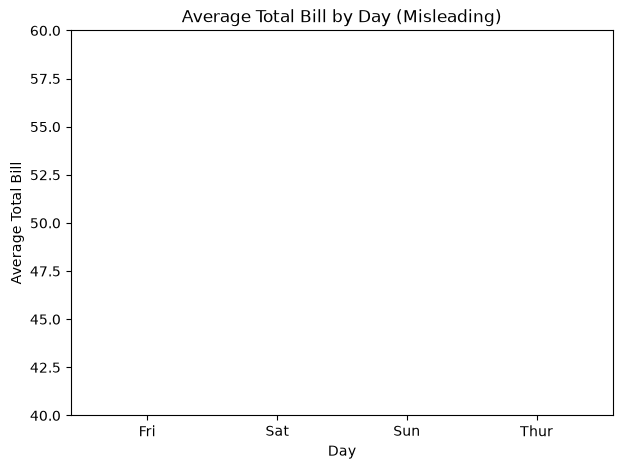

In [33]:
avg_bill = df.groupby("day")["total_bill"].mean()

plt.figure(figsize=(7,5))

plt.bar(avg_bill.index, avg_bill.values)

plt.ylim(40, 60)   # Misleading axis

plt.title("Average Total Bill by Day (Misleading)")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")

plt.show()

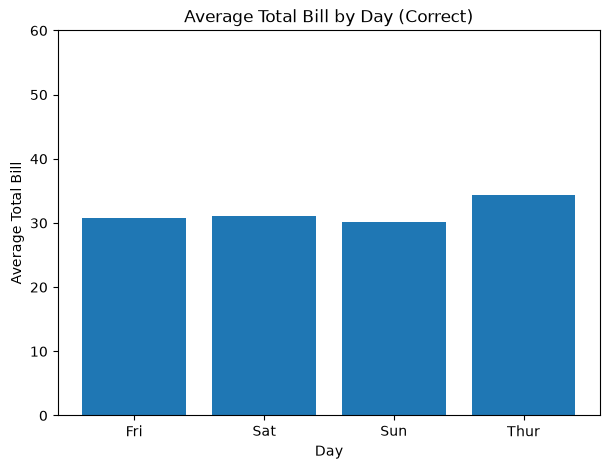

In [34]:
plt.figure(figsize=(7,5))

plt.bar(avg_bill.index, avg_bill.values)

plt.ylim(0, 60)

plt.title("Average Total Bill by Day (Correct)")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")

plt.show()